In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Alle Libraries erfolgreich geladen!")
print(f"pandas Version: {pd.__version__}")
print(f"numpy Version:  {np.__version__}")

Alle Libraries erfolgreich geladen!
pandas Version: 3.0.3
numpy Version:  2.4.6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Alle vier Dateien laden
df_lukas  = pd.read_excel('input/ems_mockdaten_lukas.xlsx',  sheet_name='incidents')
df_merjem = pd.read_excel('input/ems_mockdaten_merjem.xlsx', sheet_name='incidents')
df_mido   = pd.read_excel('input/ems_mockdaten_mido.xlsx',   sheet_name='incidents')
df_zusatz = pd.read_excel('input/ems_mockdaten_zusatz.xlsx', sheet_name='Sheet1')

# df_zusatz: Spaltennamen angleichen und Typen korrigieren
df_zusatz = df_zusatz.rename(columns={
    'incident_type_id': 'incident_type_(id)',
    'location_type_id': 'location_type_(id)',
})
df_zusatz['date'] = pd.to_datetime(df_zusatz['date'])

df = pd.concat([df_lukas, df_merjem, df_mido, df_zusatz], ignore_index=True)

# Lookup-Tabellen
incident_types = pd.read_excel('input/ems_mockdaten_lukas.xlsx', sheet_name='incident_type')
location_types = pd.read_excel('input/ems_mockdaten_lukas.xlsx', sheet_name='location_type')

print(f"Datensätze gesamt: {len(df)}")
print(f"Zeitraum: {df['date'].min().date()} bis {df['date'].max().date()}")
df.head()

In [2]:
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
df['hour']      = df['datetime'].dt.hour
df['weekday']   = df['datetime'].dt.weekday      # 0=Montag, 6=Sonntag
df['month']     = df['datetime'].dt.month
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

# Lesbare Labels mergen
df = df.merge(incident_types[['id','incident_type']], left_on='incident_type_(id)', right_on='id', how='left')
df = df.merge(location_types[['id','location_type']],  left_on='location_type_(id)',  right_on='id', how='left')

print(df.dtypes)
df.head()

date                  datetime64[us]
time                          object
PLZ                            int64
incident_type_(id)             int64
gender                           str
age                            int64
location_type_(id)             int64
datetime              datetime64[us]
hour                           int32
weekday                        int32
month                          int32
is_weekend                     int64
id_x                           int64
incident_type                    str
id_y                           int64
location_type                    str
dtype: object


,date,time,PLZ,incident_type_(id),gender,age,location_type_(id),datetime,hour,weekday,month,is_weekend,id_x,incident_type,id_y,location_type
0,2025-01-01,08:52:00,4100,9,m,70,1,2025-01-01 08:52:00,8,2,1,0,9,Krankentransport,1,Zuhause
1,2025-01-01,12:48:00,4650,5,m,80,4,2025-01-01 12:48:00,12,2,1,0,5,Verkehrsunfall,4,Verkehr
2,2025-01-01,17:31:00,4050,9,w,52,1,2025-01-01 17:31:00,17,2,1,0,9,Krankentransport,1,Zuhause
3,2025-01-01,11:18:00,4053,1,m,67,4,2025-01-01 11:18:00,11,2,1,0,1,Herz-Kreislauf,4,Verkehr
4,2025-01-01,02:22:00,4400,2,w,67,1,2025-01-01 02:22:00,2,2,1,0,2,Atemnot,1,Zuhause


In [1]:
plt.figure(figsize=(12, 4))
df.groupby('hour').size().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Einsätze nach Tageszeit', fontsize=14)
plt.xlabel('Stunde')
plt.ylabel('Anzahl Einsätze')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafik_tageszeit.png', dpi=150)
plt.show()

NameError: name 'plt' is not defined

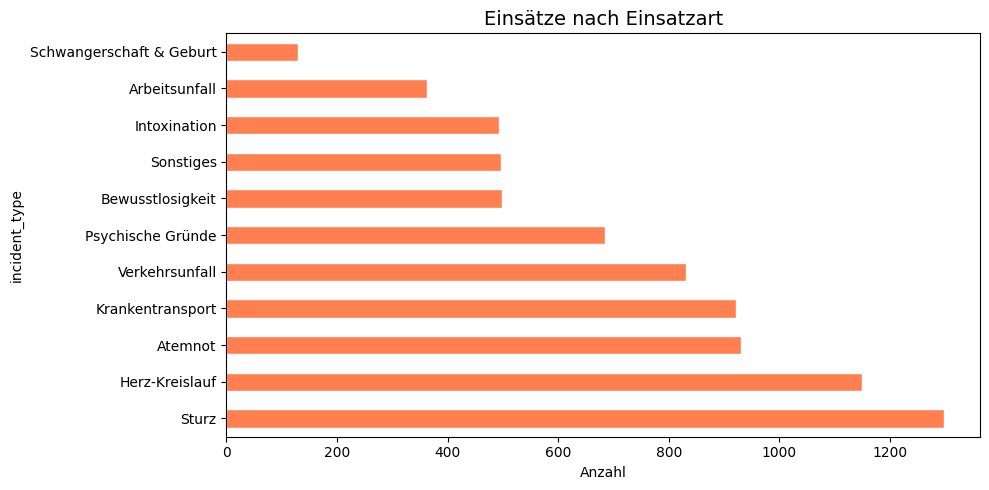

In [4]:
plt.figure(figsize=(10, 5))
df['incident_type'].value_counts().plot(kind='barh', color='coral', edgecolor='white')
plt.title('Einsätze nach Einsatzart', fontsize=14)
plt.xlabel('Anzahl')
plt.tight_layout()
plt.savefig('grafik_einsatzart.png', dpi=150)
plt.show()

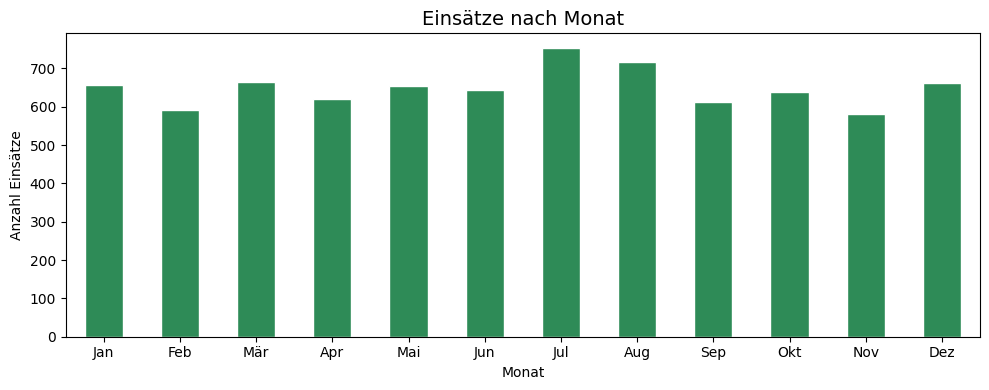

In [5]:
plt.figure(figsize=(10, 4))
monate = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
df.groupby('month').size().plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Einsätze nach Monat', fontsize=14)
plt.xlabel('Monat')
plt.ylabel('Anzahl Einsätze')
plt.xticks(range(12), monate, rotation=0)
plt.tight_layout()
plt.savefig('grafik_monat.png', dpi=150)
plt.show()